## 8.3 Object Counting Faster R-CNN

### 8.3.1 Install Supervision
<img src="resource/rf-supervision-banner.png" width="700px"><br><br>
>.
>
> ⚠️ <font color="orange">If you already create conda environment 'BelajarSuperVision', you can skip the following step then jump to part #8.3.2, </font><br>
>
>.
- Since Supervision working in `python3.8`, we need to create new conda environment with name `BelajarSuperVision` using that python version
- Open `Anaconda prompt`
- create new environment `BelajarSuperVision`
    ```
    conda create --name BelajarSuperVision python=3.8
    ```
- activate environment
    ```
    conda activate BelajarSuperVision
    ```
- run to install supervision & ultralytics
    ```
    pip install ipykernel
    pip install supervision
    pip install ultralytics
    pip install onnx --user
    pip install onnxruntime
    ```
- Close VS Code, then reopen it
- Open `6.2 supervision-object-counting.ipynb`
- Choose `BelajarSuperVision` as python environment<br>
<img src="resource/sv-image.png" width="300px">

<br><br><br><br>
### 8.3.2 Object Counting Faster R-CNN using ONNX Runtiome + SuperVision
- import library

In [1]:
import cv2
import numpy as np
import torch
import onnx
import onnxruntime as ort
import supervision as sv
import utils

utility = utils.Utils()

c:\Python\Python37\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- Define class labels

In [2]:
CLASS_LABELS = ["background", "scissors"]  # Modify according to your dataset

- load sample image

In [3]:
original_image = cv2.imread("image1.jpg")

if(original_image.shape[1] > 900) : 
    original_image = cv2.resize(original_image, (0, 0), fx=0.5,fy=0.5) # resize 50% if image to big

- Load Faster R-CNN ONNX Model into ONNX Runtime

In [4]:
# Load the ONNX model
MODEL_NAME = "fasterrcnn_resnet50_fpn_v2_scissors.onnx"
onnx_model = onnx.load(MODEL_NAME)
onnx.checker.check_model(onnx_model)

# Initialize inference with ONNX Runtime
ort_session = ort.InferenceSession(MODEL_NAME)

- run inference on input tensor to ONNX Faster R-CNN model

In [5]:
# Preprocess the frame for Faster R-CNN
image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
image_norm = (image / 255.0).astype(np.float32)
image_tensor = np.transpose(image_norm, (2, 0, 1))
image_tensor = np.expand_dims(image_tensor, axis=0) # Shape: [1, C, H, W]

# run inference
outputs = ort_session.run(None, {"input": image_tensor})
print("ONNX model outputs:", outputs[0])

ONNX model outputs: [[ 39.596375  114.6374     98.13401   153.62767  ]
 [140.24112   110.295006  184.37682   181.96605  ]
 [125.54805    70.9212    176.12206   106.803215 ]
 [ 48.1991     39.420204   99.83198    90.03096  ]
 [ 52.622593   50.111614   87.025116   86.601006 ]
 [ 37.90108    20.14341   105.20399   112.422714 ]
 [ 32.12106    99.69114    97.02401   175.37256  ]
 [ 18.947958    6.8052273 135.51979   116.87013  ]
 [124.81612    54.801674  190.3946    111.38602  ]
 [132.53484   122.33822   190.14633   159.66133  ]
 [ 42.06359   127.066086   93.42992   146.54524  ]
 [135.63087    68.29501   190.65686   193.54137  ]
 [ 31.274897   19.855276  109.707794  102.157364 ]
 [ 22.75807   117.53282   119.1923    187.20737  ]
 [127.930176   74.48713   174.18193    92.15459  ]
 [110.1275     76.872314  179.26088    98.31735  ]
 [ 50.10091    64.27859    82.740875   82.05091  ]
 [ 18.541626   16.081573   85.5779     89.517525 ]
 [138.06802   127.79399   195.9121    197.13069  ]
 [ 21.24134

- Define polygon using mouse click with `cv2.selectROI`

In [6]:
x, y, w, h = 100, 100, 300, 300

polygon = np.array([
    [x, y],
    [x+w, y],
    [x+w, y+h],
    [x, y+h]
])

- or, <font color="orange">Define polygon zone manually</font> here,
    - <i>uncomment below code to use it!</i>

In [7]:
# paste the polygon point here!
# polygon = np.array([[ 63,  61], [539,  61], [539, 601], [ 63, 601]]) # CHANGE TO YOUR OWN POLYGON

- Instantiate SuperVision Polygone Zone

In [8]:
# Create Supervision's PolygonZone for object counting in the specified polygon
h, w, _ = original_image.shape

zone = sv.PolygonZone(
    polygon=polygon,
    frame_resolution_wh=(w, h)
)

# Create Supervision annotators for boxes, labels, and the polygon zone
box_annotator = sv.BoxAnnotator()
zone_annotator = sv.PolygonZoneAnnotator(
    zone=zone,
    color=sv.Color(0, 255, 0),
    thickness=2
)

- Run object counting

[[176, 358, 438, 480], [626, 344, 823, 568], [561, 221, 787, 333], [215, 123, 446, 281], [235, 156, 388, 270]]


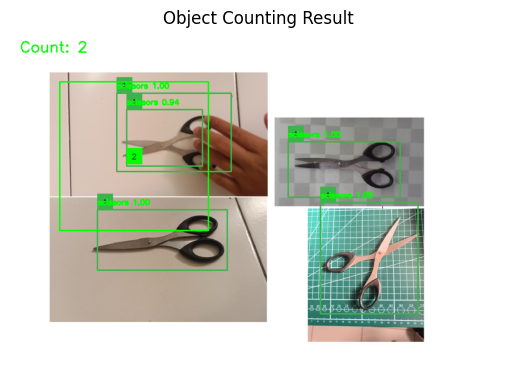

In [9]:
# =========================
# 1. FILTER DETECTION
# =========================
threshold = 0.89

mask = outputs[2] > threshold
boxes = outputs[0][mask]
labels = outputs[1][mask]
scores = outputs[2][mask]

# rescale box
boxes = utility.rescale_box(boxes, original_image, input_size=[224,224])

# =========================
# 2. CONVERT TO DETECTIONS
# =========================
detections = sv.Detections(
    xyxy=boxes,
    confidence=scores,
    class_id=labels
)

# =========================
# 3. TRIGGER ZONE
# =========================
zone.trigger(detections=detections)

# =========================
# 4. VISUALISASI
# =========================
result_image = original_image.copy()

# bounding box dari supervision
result_image = box_annotator.annotate(
    scene=result_image,
    detections=detections
)

# polygon zone
result_image = zone_annotator.annotate(scene=result_image)

# =========================
# 5. LABEL MANUAL (pengganti LabelAnnotator)
# =========================
for box, class_id, score in zip(boxes, labels, scores):
    x1, y1, x2, y2 = map(int, box)

    label = f"{CLASS_LABELS[class_id]} {score:.2f}"

    cv2.putText(result_image, label,
                (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0,255,0),
                2)

# =========================
# 6. COUNTING
# =========================
count = zone.current_count

cv2.putText(result_image, f"Count: {count}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,255,0),
            2)

# =========================
# 7. TAMPILKAN (JANGAN pakai imshow)
# =========================
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("Object Counting Result")
plt.axis("off")
plt.show()